# 13 — Embedding separability: is the editorial "triangle" a label problem?

**Question.** The held-out confusion matrix (notebook 11) showed three classes —
`policy_practice_research`, `political_environment_key_organisations`, `what_matters_ed` —
bleeding into each other (the "triangle" already flagged in notebook 08), while the
*concrete* classes (`edtech`, `four_nations`, `teacher_rrd`) stayed clean.

Is that because the **categories themselves overlap in meaning** (a label-taxonomy ceiling),
or because **our embedder is too weak** to separate them (a model ceiling)?

**Method — two complementary views:**
- **Label-guided (option a):** project the whole labelled set into 2D and measure separability with
  two embedders — **all-MiniLM-L6-v2** (production: "what the model sees") and **all-mpnet-base-v2**
  (stronger general: "would a better embedder help?"). If the triangle overlaps under *both*, the
  ceiling is the label design, not the model.
- **Unsupervised (option b):** cluster the embeddings *without* the labels and compare the discovered
  topics to the curator's 6 categories (cross-tab + ARI/NMI + TF-IDF topic readout). Independent
  evidence on whether the data's own structure supports the taxonomy.

**Input.** We embed `text_clean` (title + description) — the same input training used.
*(Note: NB11's held-out eval originally encoded title-only — a skew bug, now fixed; see the doc.)*

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.neighbors import NearestNeighbors

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()

# The six content classes the production model actually discriminates.
CONCRETE      = ['edtech', 'four_nations', 'teacher_rrd']
EDITORIAL     = ['policy_practice_research', 'political_environment_key_organisations', 'what_matters_ed']
CONTENT_CLASSES = CONCRETE + EDITORIAL

# MiniLM (production) is the embedder that matters — it's what the deployed model sees, and the
# whole analysis runs on it. MPNet is an OPTIONAL "would a stronger embedder help?" comparison;
# its ~438MB download can hang at finalisation on a flaky connection. It's commented out so the
# notebook runs unblocked. Uncomment it once it's fully cached (the embed cell skips it gracefully
# if the download fails), and the t-SNE / purity / triangle cells will simply show a second panel.
EMBEDDERS = {
    'MiniLM (production)': 'sentence-transformers/all-MiniLM-L6-v2',
    # 'MPNet (stronger)':   'sentence-transformers/all-mpnet-base-v2',
}
print('ROOT =', ROOT)

ROOT = /workspaces/AM2_erp_programme_automataion


In [2]:
# --- Load the full labelled set (train + val = newsletters 1-104) -----------------
def find_csv(name):
    for p in [ROOT/'data'/'processed'/name, ROOT/'data'/'modelling'/name]:
        if p.exists():
            return p
    raise FileNotFoundError(name)

frames = []
for name in ['train.csv', 'val.csv']:
    try:
        frames.append(pd.read_csv(find_csv(name)))
    except FileNotFoundError as e:
        print('skip', e)
df = pd.concat(frames, ignore_index=True)

# Label column: prefer new_theme, fall back to target.
label_col = 'new_theme' if 'new_theme' in df.columns else 'target'
df['label'] = df[label_col].astype(str)

# Input text built EXACTLY as training did: prefer text_clean, else text, else title+description.
def build_text(row):
    for c in ['text_clean', 'text']:
        if c in row and pd.notna(row[c]) and str(row[c]).strip():
            return str(row[c])
    title = str(row['title']) if pd.notna(row.get('title')) else ''
    desc  = str(row['description']) if pd.notna(row.get('description')) else ''
    return (title + '. ' + desc).strip()

df['model_text'] = df.apply(build_text, axis=1)
df = df[df['label'].isin(CONTENT_CLASSES)].copy().reset_index(drop=True)
df = df[df['model_text'].str.len() > 0].reset_index(drop=True)

print(f'Items: {len(df)}   text source col: '
      f"{'text_clean' if 'text_clean' in df.columns else ('text' if 'text' in df.columns else 'title+description')}")
print(df['label'].value_counts().to_string())

Items: 1416   text source col: text
label
political_environment_key_organisations    315
what_matters_ed                            256
teacher_rrd                                233
edtech                                     226
policy_practice_research                   221
four_nations                               165


## Embed the articles
Runs on **MiniLM (production)** by default — fast, already cached. If you re-enable MPNet in the
config cell, it downloads ~438MB on first run and is added as a second comparison (skipped gracefully
if the download fails).

In [3]:
texts = df['model_text'].tolist()
labels = df['label'].values
embeddings = {}
for nice, model_id in EMBEDDERS.items():
    print('encoding with', nice, '...')
    try:
        enc = SentenceTransformer(model_id)
        embeddings[nice] = enc.encode(texts, show_progress_bar=True, normalize_embeddings=True)
        print('  shape', embeddings[nice].shape)
    except Exception as e:
        print(f'  SKIPPED {nice}: {type(e).__name__}: {e}')

assert embeddings, "No embedder loaded — check the network / model ids."
print('\nEmbedders available downstream:', list(embeddings))

encoding with MiniLM (production) ...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/45 [00:00<?, ?it/s]

  shape (1416, 384)

Embedders available downstream: ['MiniLM (production)']


## 2D projection — do the editorial classes form their own clusters or sit on top of each other?
Colour = true label. Solid = concrete classes, hatched markers = the editorial triangle.

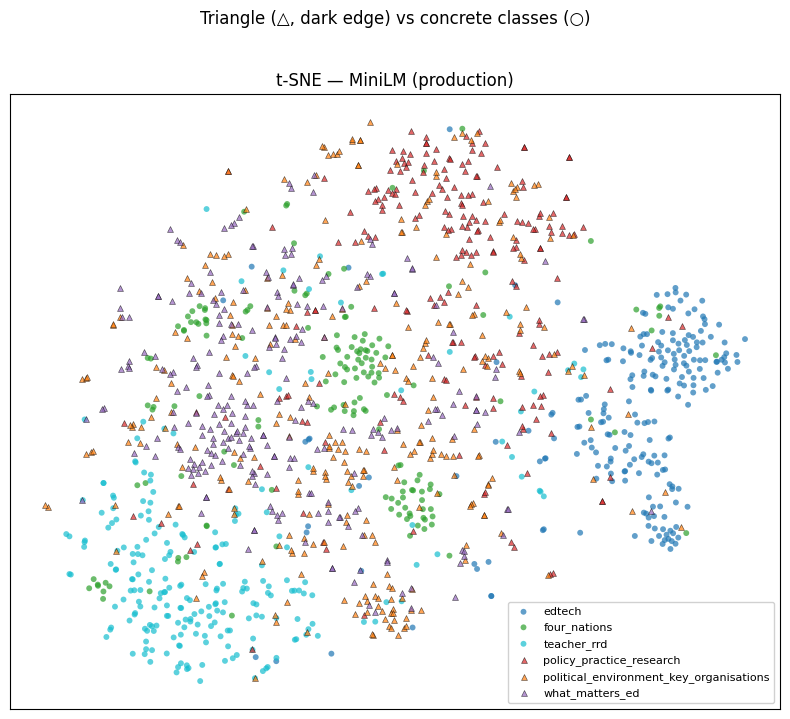

In [4]:
palette = {
    'edtech': '#1f77b4', 'four_nations': '#2ca02c', 'teacher_rrd': '#17becf',
    'policy_practice_research': '#d62728',
    'political_environment_key_organisations': '#ff7f0e',
    'what_matters_ed': '#9467bd',
}

fig, axes = plt.subplots(1, len(embeddings), figsize=(8*len(embeddings), 7))
axes = np.atleast_1d(axes)
for ax, (nice, emb) in zip(axes, embeddings.items()):
    perp = max(5, min(30, (len(emb) - 1) // 3))
    xy = TSNE(n_components=2, init='pca', perplexity=perp, random_state=42).fit_transform(emb)
    for cls in CONTENT_CLASSES:
        m = labels == cls
        ax.scatter(xy[m, 0], xy[m, 1], s=18, alpha=0.7, c=palette[cls],
                   marker=('o' if cls in CONCRETE else '^'),
                   edgecolors=('none' if cls in CONCRETE else 'black'), linewidths=0.4,
                   label=cls)
    ax.set_title(f't-SNE — {nice}')
    ax.set_xticks([]); ax.set_yticks([])
axes[0].legend(loc='best', fontsize=8, framealpha=0.9)
plt.suptitle('Triangle (△, dark edge) vs concrete classes (○)', y=1.02)
plt.tight_layout(); plt.show()

## Quantify separability — don't trust the eyeball
Two metrics, per embedder:
- **Neighbourhood purity** (k=10): of each item's 10 nearest neighbours, what fraction share its label? Low purity = the class overlaps its neighbours. The editorial trio should score low.
- **Silhouette** (cosine): how tight/separated each class cluster is. Negative = the class is, on average, closer to a *different* class than its own.

In [5]:
def neighbourhood_purity(emb, labels, k=10):
    nn = NearestNeighbors(n_neighbors=k+1, metric='cosine').fit(emb)
    _, idx = nn.kneighbors(emb)
    idx = idx[:, 1:]  # drop self
    labels = np.asarray(labels)
    return np.array([(labels[neigh] == labels[i]).mean() for i, neigh in enumerate(idx)])

rows = []
for nice, emb in embeddings.items():
    pur = neighbourhood_purity(emb, labels)
    sil = silhouette_samples(emb, labels, metric='cosine')
    for cls in CONTENT_CLASSES:
        m = labels == cls
        rows.append({'embedder': nice, 'class': cls, 'group': 'editorial' if cls in EDITORIAL else 'concrete',
                     'n': int(m.sum()), 'purity_k10': round(pur[m].mean(), 3),
                     'silhouette': round(sil[m].mean(), 3)})
report = pd.DataFrame(rows)
for nice in embeddings:
    print(f'\n=== {nice} ===')
    print(report[report.embedder == nice].drop(columns='embedder').to_string(index=False))
    sub = report[report.embedder == nice]
    print(f"  group mean purity   concrete={sub[sub.group=='concrete'].purity_k10.mean():.3f}  "
          f"editorial={sub[sub.group=='editorial'].purity_k10.mean():.3f}")


=== MiniLM (production) ===
                                  class     group   n  purity_k10  silhouette
                                 edtech  concrete 226       0.792       0.081
                           four_nations  concrete 165       0.611       0.045
                            teacher_rrd  concrete 233       0.669       0.102
               policy_practice_research editorial 221       0.522       0.015
political_environment_key_organisations editorial 315       0.450      -0.029
                        what_matters_ed editorial 256       0.491       0.018
  group mean purity   concrete=0.691  editorial=0.488


## The triangle, head-on: how much do the three editorial classes overlap each other?
Restrict to the trio and compute pairwise centroid cosine distance. Small distance + low
silhouette = the categories are not separable by content; the boundary lives in the curator's
head, not the text.

In [6]:
from itertools import combinations
for nice, emb in embeddings.items():
    m = np.isin(labels, EDITORIAL)
    sub_emb, sub_lab = emb[m], labels[m]
    cents = {c: sub_emb[sub_lab == c].mean(0) for c in EDITORIAL}
    print(f'\n=== {nice} — editorial trio centroid cosine distance (0=identical) ===')
    for a, b in combinations(EDITORIAL, 2):
        ca, cb = cents[a], cents[b]
        cos = float(ca @ cb / (np.linalg.norm(ca) * np.linalg.norm(cb)))
        print(f'  {a[:18]:>18} <-> {b[:18]:<18}  dist={1-cos:.3f}')
    print(f'  trio silhouette (3-way): {silhouette_score(sub_emb, sub_lab, metric="cosine"):.3f}')
    cm = np.isin(labels, CONCRETE)
    print(f'  concrete silhouette (3-way): {silhouette_score(emb[cm], labels[cm], metric="cosine"):.3f}')


=== MiniLM (production) — editorial trio centroid cosine distance (0=identical) ===
  policy_practice_re <-> political_environm  dist=0.115
  policy_practice_re <-> what_matters_ed     dist=0.216
  political_environm <-> what_matters_ed     dist=0.079
  trio silhouette (3-way): 0.021
  concrete silhouette (3-way): 0.101


## Unsupervised discovery — what categories does the *data* suggest?

Everything above is **label-guided** (option a): given the curator's labels, how separable are they?
This section is **unsupervised** (option b): cluster the embeddings *without looking at the labels*,
read out what each cluster is about, then compare the discovered clusters to the curator's 6 categories.

- **Method:** KMeans (k=6 to match the curator's taxonomy) on the production MiniLM embeddings, then a
  TF-IDF "topic readout" of the top terms per cluster. *(KMeans + TF-IDF keeps this dependency-light;
  the heavier standard tool is **BERTopic** = UMAP + HDBSCAN + c-TF-IDF, which auto-picks the cluster
  count — worth it only if we want the data to choose k.)*
- **The payoff is the cross-tab + ARI/NMI:** if the concrete classes each get their own clean cluster
  but the editorial triangle smears across shared clusters, the data's *own* structure agrees the
  triangle isn't separable from content — a third, independent line of evidence (after the confusion
  matrix and the label-guided silhouette).

In [7]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# Cluster the production embeddings WITHOUT using labels. k=6 to match the curator's taxonomy.
emb = embeddings['MiniLM (production)']
K = len(CONTENT_CLASSES)
clusters = KMeans(n_clusters=K, n_init=10, random_state=42).fit_predict(emb)

# Cross-tab: discovered cluster (rows) vs curator label (cols).
ct = pd.crosstab(pd.Series(clusters, name='cluster'),
                 pd.Series(labels,  name='curator_label'))
ct = ct[CONTENT_CLASSES]  # column order: concrete first, then the triangle
print('=== Discovered clusters (rows) vs curator labels (cols) ===')
print(ct.to_string())

# Per-cluster: which curator label dominates, and how pure is the cluster?
print('\n=== Cluster purity (dominant curator label per cluster) ===')
for c in range(K):
    row = ct.loc[c]
    print(f'  cluster {c}: n={int(row.sum()):3d}  dominant={row.idxmax():42s} purity={row.max()/row.sum():.2f}')

# Single-number agreement between the data's clusters and the curator's labels.
print(f"\nAgreement of discovered clusters with curator labels:")
print(f"  Adjusted Rand Index (ARI): {adjusted_rand_score(labels, clusters):.3f}   (0=random, 1=identical)")
print(f"  Normalised Mutual Info (NMI): {normalized_mutual_info_score(labels, clusters):.3f}")

=== Discovered clusters (rows) vs curator labels (cols) ===
curator_label  edtech  four_nations  teacher_rrd  policy_practice_research  political_environment_key_organisations  what_matters_ed
cluster                                                                                                                             
0                  18            14            4                       136                                       61               28
1                  20            17           26                        11                                       51              110
2                  28            69           29                        51                                      140               30
3                 110             6            1                         4                                        2                1
4                  41            38            3                        15                                       52               85
5        

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Topic readout: top distinctive terms per discovered cluster (what is each cluster ABOUT?).
vec = TfidfVectorizer(max_features=3000, stop_words='english', ngram_range=(1, 2), min_df=3)
tfidf = vec.fit_transform(texts)
terms = np.array(vec.get_feature_names_out())

print('=== Topic readout — top terms per discovered cluster ===')
for c in range(K):
    mask = clusters == c
    mean_tfidf = np.asarray(tfidf[mask].mean(axis=0)).ravel()
    top = terms[mean_tfidf.argsort()[::-1][:10]]
    print(f'  cluster {c} (≈{ct.loc[c].idxmax()}):  {", ".join(top)}')

=== Topic readout — top terms per discovered cluster ===
  cluster 0 (≈policy_practice_research):  policy, research, government, public, evidence, blog, local, report, engagement, upen
  cluster 1 (≈what_matters_ed):  school, schools, absence, pupils, schoolsweek, pupil, report, attendance, education, children
  cluster 2 (≈political_environment_key_organisations):  education, curriculum, ofsted, schools, new, report, school, learning, review, wales
  cluster 3 (≈edtech):  ai, education, intelligence, artificial, artificial intelligence, ai education, generative, schools, use, generative ai
  cluster 4 (≈what_matters_ed):  children, child, poverty, young, child poverty, people, report, young people, uk, government
  cluster 5 (≈teacher_rrd):  teacher, teachers, recruitment, retention, teaching, pay, schools, recruitment retention, teacher recruitment, report


### How to read the unsupervised result

- **Concrete classes should each "own" a high-purity cluster** (edtech, four_nations, teacher_rrd) —
  the data agrees they're real, distinct topics.
- **The triangle is the tell:** if `policy_practice_research`, `political_environment_key_organisations`
  and `what_matters_ed` *share* clusters (no cluster is cleanly dominated by one of them, or they split
  across several), then the data's own structure can't separate them either → **label-taxonomy ceiling
  confirmed by a third method.**
- **ARI / NMI** quantify the overall agreement between the data's clusters and the curator's 6 labels.
  Moderate (not high) is expected and is itself the finding: the curator's taxonomy is an *editorial*
  framework, only partly recoverable from content alone.
- **Topic readout** tells you what each discovered cluster is really about — useful for spotting
  categories the taxonomy misses or conflates.
- *Next step if needed:* swap KMeans+TF-IDF for **BERTopic** to let the data choose the number of
  topics and get cleaner topic descriptions.

## How to read this (analysis notes, not the write-up)

- **If editorial purity/silhouette are low under BOTH embedders** → label-taxonomy ceiling.
  MPNet (the stronger model) won't rescue it. Evidence for: merge / hierarchical / multi-label,
  or an LLM with explicit boundary rules in the prompt (notebook 06 already shows Claude does
  better here precisely because the prompt disambiguates the triangle).
- **If MPNet sharply separates the trio but MiniLM doesn't** → it's a model lever: a stronger
  embedder is worth the cost.
- **Compare concrete vs editorial silhouette** — the *gap* is the headline number: it shows the
  model isn't uniformly weak, it's weak exactly where the categories overlap in meaning.
- Cross-check the centroid distances against the NB11 confusion matrix: the closest centroid pair
  should be the most-confused cell (policy ↔ political).